# Raisin Detective – Preprocessing and Baseline Models

In this notebook, we prepare the Raisin dataset for supervised machine learning.

We will separate the features and target variable, encode the target labels, split the data into training and test sets, and build our first baseline model using a Decision Tree classifier.

The baseline model gives us a first reference point before moving on to more advanced ensemble models such as Random Forest and XGBoost.

In [3]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path
from sklearn.tree import plot_tree

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

In [4]:
sns.set_theme(style="whitegrid", context="notebook")

plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.titlesize"] = 16
plt.rcParams["axes.labelsize"] = 12

In [5]:
PROJECT_ROOT = Path("../..")
DATA_RAW = PROJECT_ROOT / "data" / "raw"

csv_path = DATA_RAW / "raisin_dataset.csv"

df = pd.read_csv(csv_path)

df.head()

,Area,MajorAxisLength,MinorAxisLength,Eccentricity,ConvexArea,Extent,Perimeter,Class
0,87524,442.246011,253.291155,0.819738,90546,0.758651,1184.040,Kecimen
1,75166,406.690687,243.032436,0.801805,78789,0.684130,1121.786,Kecimen
2,90856,442.267048,266.328318,0.798354,93717,0.637613,1208.575,Kecimen
3,45928,286.540559,208.760042,0.684989,47336,0.699599,844.162,Kecimen
4,79408,352.190770,290.827533,0.564011,81463,0.792772,1073.251,Kecimen


## Prepare Features and Target

We separate the dataset into features (`X`) and target (`y`).  
The features are the numerical measurements of each raisin, and the target is the raisin class: Kecimen or Besni.

In [6]:
X = df.drop(columns="Class")
y = df["Class"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (900, 7)
y shape: (900,)


In [7]:
label_encoder = LabelEncoder()

y_encoded = label_encoder.fit_transform(y)

class_mapping = dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_)))

class_mapping

{'Besni': np.int64(0), 'Kecimen': np.int64(1)}

## Target Encoding

The target variable `Class` contains two categories: Besni and Kecimen.  
Since machine learning models work with numerical values, we encoded the class labels into 0 and 1.

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (720, 7)
X_test shape: (180, 7)
y_train shape: (720,)
y_test shape: (180,)


In [9]:
print("Training class distribution:")
print(pd.Series(y_train).value_counts())

print("\nTest class distribution:")
print(pd.Series(y_test).value_counts())

Training class distribution:
0    360
1    360
Name: count, dtype: int64

Test class distribution:
0    90
1    90
Name: count, dtype: int64


## Train/Test Split

The dataset was split into 80% training data and 20% test data.  
We used stratification to keep the same class distribution in both sets.

Because the original dataset is perfectly balanced, the training and test sets also remain balanced.

In [10]:
decision_tree = DecisionTreeClassifier(random_state=42)

decision_tree.fit(X_train, y_train)

y_pred_dt = decision_tree.predict(X_test)

In [11]:
dt_accuracy = accuracy_score(y_test, y_pred_dt)

print(f"Decision Tree Accuracy: {dt_accuracy:.4f}")

Decision Tree Accuracy: 0.8444


In [12]:
print(classification_report(
    y_test,
    y_pred_dt,
    target_names=label_encoder.classes_
))

              precision    recall  f1-score   support

       Besni       0.90      0.78      0.83        90
     Kecimen       0.80      0.91      0.85        90

    accuracy                           0.84       180
   macro avg       0.85      0.84      0.84       180
weighted avg       0.85      0.84      0.84       180



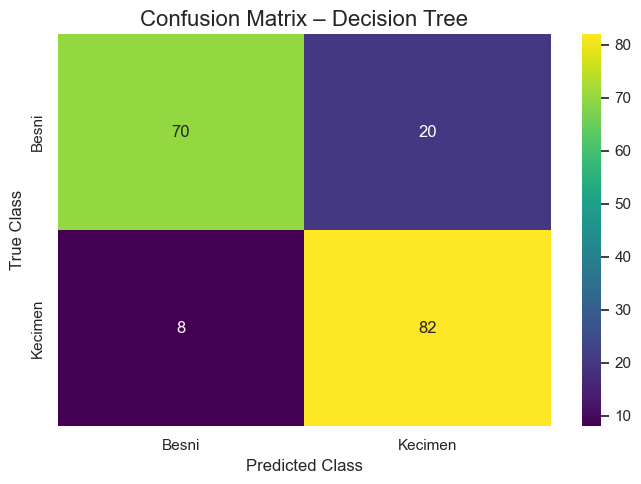

In [13]:
cm_dt = confusion_matrix(y_test, y_pred_dt)

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm_dt,
    annot=True,
    fmt="d",
    cmap="viridis",
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)

plt.title("Confusion Matrix – Decision Tree")
plt.xlabel("Predicted Class")
plt.ylabel("True Class")

plt.tight_layout()
plt.show()

In [14]:
## Baseline Model: Decision Tree

The Decision Tree model is used as a first baseline model.  
It gives us an initial understanding of how well a simple tree-based model can classify the raisin types.

The confusion matrix shows how many raisins were correctly and incorrectly classified for each class.

SyntaxError: invalid syntax (348281983.py, line 3)

In [ ]:
model_results = pd.DataFrame({
    "Model": ["Decision Tree"],
    "Accuracy": [dt_accuracy]
})

model_results

,Model,Accuracy
0,Decision Tree,0.844444


In [ ]:
## Baseline Result Summary

The Decision Tree baseline model gives us a first reference point before testing more advanced ensemble methods.

If the Decision Tree performs well, it means that the raisin classes can be separated using simple decision rules.  
However, Decision Trees can easily overfit, so the next step is to use Random Forest, which combines many trees to create a more stable model.

In [ ]:
## Decision Tree Result Interpretation

The Decision Tree baseline model achieved an accuracy of approximately 84%.

The model performs better on the Kecimen class than on the Besni class. For Kecimen, the recall is 0.91, which means that the model correctly identifies most Kecimen raisins. For Besni, the recall is lower at 0.78, meaning that some Besni raisins are incorrectly classified as Kecimen.

This baseline result shows that the dataset contains useful patterns for classification. However, Decision Trees can be sensitive to small changes in the data and may overfit. Therefore, the next step is to test Random Forest, which combines many decision trees and usually gives a more stable model.

In [15]:
dt_visual = DecisionTreeClassifier(
    max_depth=3,
    random_state=42
)

dt_visual.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,3
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


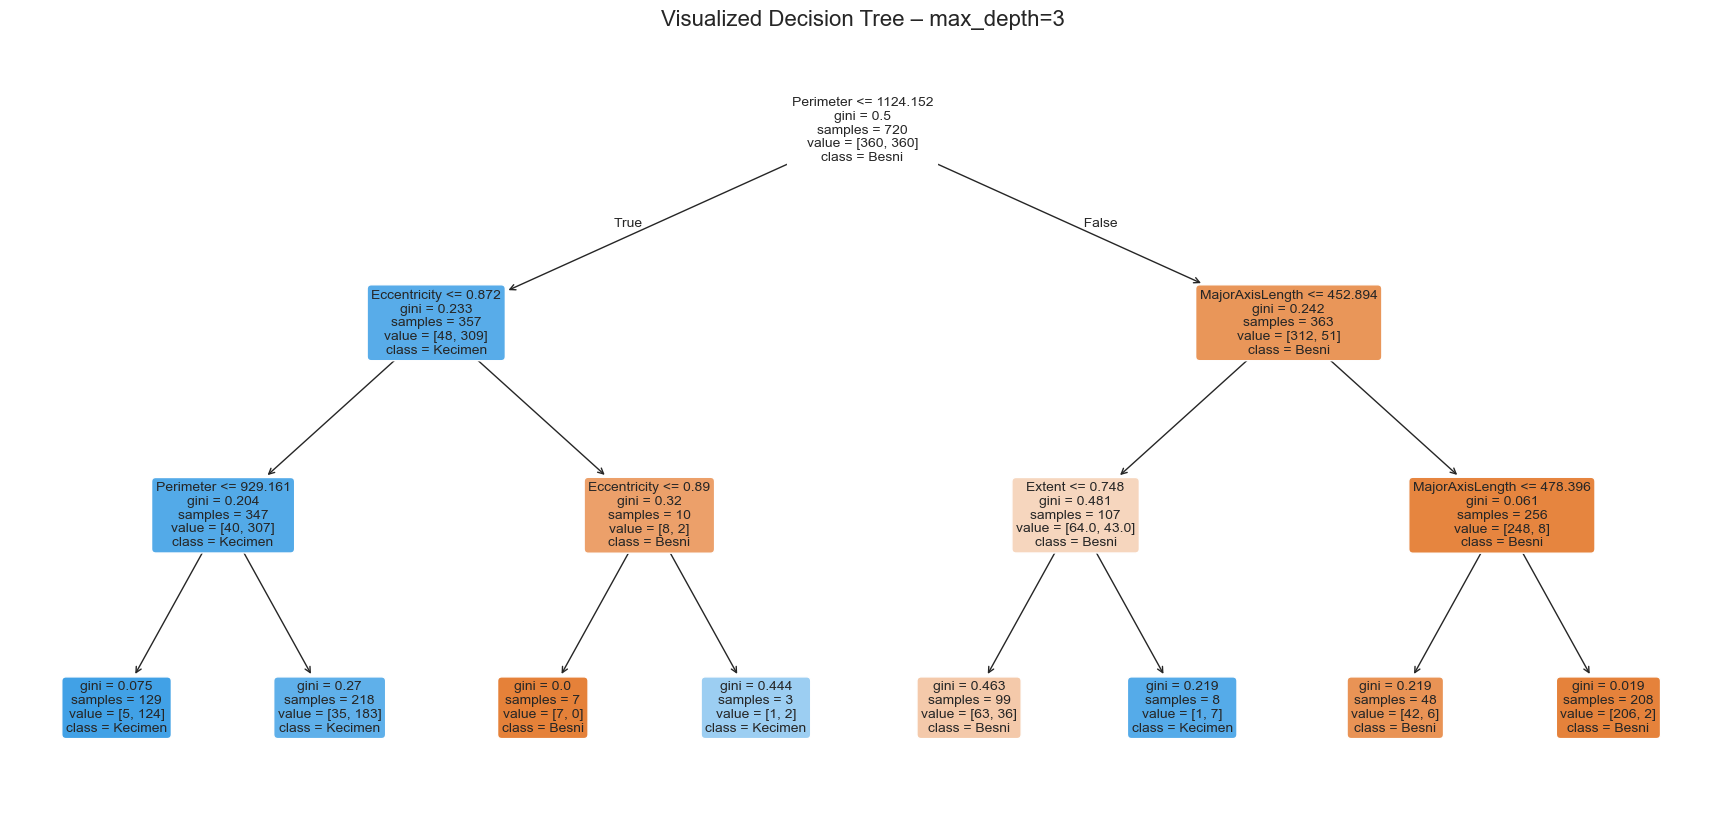

In [16]:
plt.figure(figsize=(22, 10))

plot_tree(
    dt_visual,
    feature_names=X.columns,
    class_names=label_encoder.classes_,
    filled=True,
    rounded=True,
    fontsize=10
)

plt.title("Visualized Decision Tree – max_depth=3")
plt.show()

## Visualized Decision Tree

To better understand how a Decision Tree makes predictions, we created a simplified tree with `max_depth=3`.

This visualization shows which features the model uses first when separating the two raisin classes. A smaller tree is easier to interpret and helps explain the decision-making process before moving on to more complex ensemble models such as Random Forest.